# Social Media Engagement Analytics — Module-End Assignment 5
**Dataset:** `social_media_engagement_5000.csv`


In [2]:
    # --- Core libraries ---
import numpy as np                     # array operations required by Task 1
import pandas as pd                    # DataFrame loading, cleaning, wrangling
import matplotlib.pyplot as plt        # Matplotlib static plots
import seaborn as sns                  # Seaborn statistical plots
import plotly.express as px            # Plotly interactive charts

pd.set_option("display.max_columns", None)   # show all columns when printing, so nothing is hidden
sns.set_style("whitegrid")                   # a clean, readable default background for every Seaborn plot


## Task 1 — Data Import & Setup

In [2]:
# Read the CSV straight from disk into a DataFrame. This is the standard, fastest way
# to bring tabular data into pandas; every later task operates on this `df`.
df = pd.read_csv("social_media_engagement_5000.csv")

print("Shape (rows, columns):", df.shape)   # quick sanity check on how much data we have
df.head()                                    # preview the first 5 rows to confirm columns/format look right


Shape (rows, columns): (5000, 19)


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [3]:
# Check the data type pandas inferred for every column. This tells us which columns
# need explicit conversion (e.g. dates stored as text, booleans stored as strings, etc.).
df.dtypes


user_id               int64
age                 float64
gender                  str
country                 str
post_id               int64
post_type               str
post_category           str
likes               float64
comments            float64
shares              float64
watch_time_sec        int64
impression_count      int64
posted_at               str
follower_count        int64
is_verified            bool
device_type             str
sentiment               str
hashtags                str
engagement_rate     float64
dtype: object

In [4]:
# 'posted_at' is loaded as plain text (object/string) because pandas doesn't guess
# dates automatically. We convert it to a real datetime dtype so we can do date arithmetic,
# extract day/month, sort chronologically, and resample time series later.
# format="%d-%m-%Y" tells pandas exactly how to parse "17-12-2022" (day-month-year).
df["posted_at"] = pd.to_datetime(df["posted_at"], format="%d-%m-%Y")

print(df["posted_at"].dtype)                 # confirm it is now datetime64
print(df["posted_at"].min(), "to", df["posted_at"].max())   # the date range the data covers


datetime64[us]
2022-01-01 00:00:00 to 2023-12-31 00:00:00


In [5]:
# --- NumPy array operations (required by the brief) ---
# Pull a numeric column out as a NumPy array to demonstrate basic array-level operations
# (pandas Series are backed by NumPy arrays under the hood, so .to_numpy() exposes that).
likes_array = df["likes"].to_numpy()

print("Type:", type(likes_array))                       # confirms it's a numpy.ndarray, not a Series
print("Mean likes (NumPy):", np.nanmean(likes_array))    # nanmean ignores NaNs, unlike np.mean
print("Max likes (NumPy):", np.nanmax(likes_array))      # highest number of likes in the dataset
print("Min likes (NumPy):", np.nanmin(likes_array))      # lowest number of likes in the dataset
print("Std dev likes (NumPy):", np.nanstd(likes_array))  # spread of the likes distribution

# Vectorized array arithmetic: scale likes by 1.1 (e.g. simulate a 10% growth scenario)
# without writing a Python loop — NumPy applies the operation to every element at once.
likes_scaled = likes_array * 1.1
print("First 5 scaled values:", likes_scaled[:5])


Type: <class 'numpy.ndarray'>
Mean likes (NumPy): 10107.043711340206
Max likes (NumPy): 19998.0
Min likes (NumPy): 10.0
Std dev likes (NumPy): 5789.222332204695
First 5 scaled values: [ 7712.1 12925.   5348.2  5885.  13950.2]


## Task 2 — Data Cleaning

### 2a. Detecting missing data

In [6]:
# isnull() (alias isna()) marks every cell True/False for missing; summing a boolean
# column counts how many True (i.e. missing) values it has.
missing_counts = df.isnull().sum()
print(missing_counts[missing_counts > 0])     # only print columns that actually have gaps

# Same information as a percentage — useful to judge whether a column is barely affected
# (safe to impute) or so damaged that it needs a different strategy.
print("\nPercent missing:\n", (missing_counts[missing_counts > 0] / len(df) * 100).round(2))


age          150
gender       150
likes        150
comments     150
shares       150
sentiment    150
dtype: int64

Percent missing:
 age          3.0
gender       3.0
likes        3.0
comments     3.0
shares       3.0
sentiment    3.0
dtype: float64


### 2b. Handling missing data
`age`, `gender`, `sentiment` are missing ~3% of rows (150 out of 5000) — safe to impute.
`likes`, `comments`, `shares` are also missing ~3% — these are core numeric engagement
metrics, so we impute with the **median** (robust to the outliers we saw in `.describe()`)
rather than the mean.

In [7]:
# Numeric columns -> fill with median (median resists being pulled by extreme outliers,
# unlike the mean, which is important here since likes/comments/shares are right-skewed).
for col in ["likes", "comments", "shares"]:
    median_value = df[col].median()             # compute the middle value of the non-null entries
    df[col] = df[col].fillna(median_value)       # replace NaNs in that column with the median

# 'age' is numeric but roughly uniform (13-64), so median is still the safest single-value fill.
df["age"] = df["age"].fillna(df["age"].median())

# Categorical columns -> fill with mode (the most common category), since mean/median
# don't make sense for text labels like 'Male'/'Female' or 'positive'/'negative'.
for col in ["gender", "sentiment"]:
    mode_value = df[col].mode()[0]               # mode() can return multiple values if tied; [0] takes the first
    df[col] = df[col].fillna(mode_value)

print("Missing values remaining:\n", df.isnull().sum().sum(), "total nulls left in the dataset")


Missing values remaining:
 0 total nulls left in the dataset


*(For reference, `dropna()` and forward/backward-fill are the other tools requested by
the brief. `dropna(subset=["likes"])` would remove any row still missing a critical value,
and `df["col"].fillna(method="ffill")` / `"bfill"` are the right choice for a genuinely
sequential/time-ordered field. We didn't need either here since imputing with
median/mode preserved all 5000 rows without introducing bias.)*

### 2c. Duplicate handling

In [8]:
# duplicated() flags rows that are exact repeats of an earlier row; sum() counts them.
duplicate_count = df.duplicated().sum()
print("Number of fully duplicate rows:", duplicate_count)

# drop_duplicates() removes repeats, keeping the first occurrence of each.
# It's safe to run even when the count is 0 (as here) so the pipeline stays robust
# if this script is re-run on a different/dirtier extract of the same data.
df = df.drop_duplicates()
print("Shape after de-duplication:", df.shape)


Number of fully duplicate rows: 0
Shape after de-duplication: (5000, 19)


### 2d. Data formatting — fix dtypes, standardize categories, correct unrealistic values

In [9]:
# --- Fix incorrect data types ---
# 'is_verified' should be a true boolean (it already loaded as bool here, but we cast
# explicitly so the pipeline is safe even if a messier CSV loads it as text "TRUE"/"FALSE").
df["is_verified"] = df["is_verified"].astype(bool)

# IDs are identifiers, not quantities to do math on — keeping them as plain integers
# (already the case) avoids pandas ever trying to average a user_id by mistake.
df["user_id"] = df["user_id"].astype(int)
df["post_id"] = df["post_id"].astype(int)


In [10]:
# --- Standardize categorical labels ---
# Strip stray whitespace and force consistent Title Case so 'male', ' Male', 'MALE'
# would all collapse to one clean category (protects us even though this extract is already tidy).
for col in ["gender", "post_type", "post_category", "device_type", "sentiment", "country"]:
    df[col] = df[col].astype(str).str.strip().str.lower()

# Gender and sentiment read better capitalized for charts/labels; post_type/category/device
# are kept lowercase since that's how the brief refers to them (e.g. 'video', 'mobile').
df["gender"] = df["gender"].str.title()
df["sentiment"] = df["sentiment"].str.title()

print(df["gender"].unique())
print(df["sentiment"].unique())


<StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str
<StringArray>
['Negative', 'Positive', 'Neutral']
Length: 3, dtype: str


In [11]:
# --- Correct unrealistic values in likes, comments, shares ---
# Use the IQR (Interquartile Range) rule: anything beyond 1.5x the IQR above Q3 is
# treated as an unrealistic outlier and capped (not dropped, so we don't lose whole rows
# over one noisy column) down to that upper bound.
def cap_outliers_iqr(series):
    q1, q3 = series.quantile([0.25, 0.75])       # 25th and 75th percentile
    iqr = q3 - q1                                # interquartile range = spread of the middle 50%
    upper_bound = q3 + 1.5 * iqr                 # standard Tukey fence for outliers
    lower_bound = max(0, q1 - 1.5 * iqr)          # engagement counts can't be negative, so floor at 0
    return series.clip(lower=lower_bound, upper=upper_bound)   # squash values outside the fence to the fence

for col in ["likes", "comments", "shares"]:
    before_max = df[col].max()
    df[col] = cap_outliers_iqr(df[col])
    print(f"{col}: max went from {before_max:.0f} to {df[col].max():.0f} after capping")

# engagement_rate should conceptually sit between 0 and 100 (%); a handful of rows exceed
# 100 because of very low impression counts relative to likes — cap those at 100 as unrealistic.
unrealistic_rate_count = (df["engagement_rate"] > 100).sum()
df["engagement_rate"] = df["engagement_rate"].clip(upper=100)
print(f"\nCapped {unrealistic_rate_count} unrealistic engagement_rate values (>100%) down to 100.")


likes: max went from 19998 to 19998 after capping
comments: max went from 2999 to 2999 after capping
shares: max went from 1999 to 1999 after capping

Capped 3 unrealistic engagement_rate values (>100%) down to 100.


### 2e. Feature cleaning — hashtag count & sentiment labels

In [12]:
# 'hashtags' is a single string like '#foodie #travel #love'. Counting the '#' characters
# (or splitting on whitespace) gives us how many hashtags were used per post — a useful
# numeric feature for later correlation/groupby analysis.
df["hashtag_count"] = df["hashtags"].str.count("#")

print(df[["hashtags", "hashtag_count"]].head())


                hashtags  hashtag_count
0  #foodie #travel #love              3
1               #fitness              1
2                #foodie              1
3    #music #foodie #fun              3
4                #travel              1


In [13]:
# Sentiment labels were already imputed and title-cased above; here we make sure only
# the three expected categories exist (defensive check — catches typos like 'Postive').
valid_sentiments = {"Positive", "Negative", "Neutral"}
unexpected = set(df["sentiment"].unique()) - valid_sentiments
print("Unexpected sentiment labels found:", unexpected if unexpected else "None — all clean")


Unexpected sentiment labels found: None — all clean


## Task 3 — Data Exploration using Pandas

In [14]:
# .head() / .tail() -> first/last rows; .shape -> (rows, cols); .columns -> column names
print("First 3 rows:")
display(df.head(3))
print("\nLast 3 rows:")
display(df.tail(3))
print("\nShape:", df.shape)
print("Columns:", list(df.columns))


First 3 rows:


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43.0,Female,brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,Negative,#foodie #travel #love,0.190862,3
1,10860,33.0,Male,brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,Negative,#fitness,0.201493,1
2,86820,32.0,Female,uk,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,Positive,#foodie,0.137345,1



Last 3 rows:


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
4997,67021,63.0,Female,usa,273595,text,travel,13487.0,1497.0,167.0,7466,23680,2023-04-06,483550,False,desktop,Positive,#lifestyle #tech,0.679688,2
4998,29800,13.0,Female,germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,tablet,Positive,#reels #love #fitness,0.223518,3
4999,73400,54.0,Other,japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,2023-03-04,585760,False,desktop,Neutral,#foodie #lifestyle #fashion,1.203527,3



Shape: (5000, 20)
Columns: ['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate', 'hashtag_count']


In [15]:
# .info() prints dtype + non-null count per column in one summary view;
# .dtypes gives just the type mapping, useful when you want it as a Series to filter on.
df.info()
print()
print(df.dtypes)


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   float64       
 2   gender            5000 non-null   str           
 3   country           5000 non-null   str           
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   str           
 6   post_category     5000 non-null   str           
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[us]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 non-null   b

In [16]:
# .describe() computes count, mean, std, min, quartiles, max for every numeric column —
# the fastest way to get a feel for scale and spread across the whole dataset at once.
df.describe()


,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,10106.997400,1502.039800,1002.9106,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.940518,1.998600
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.0000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.0000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,1.000000
50%,54374.500000,38.000000,548077.500000,10105.500000,1497.000000,1012.0000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2.000000
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,100.000000,3.000000
std,26090.370121,14.687151,260646.957267,5702.293017,856.393312,570.8552,2308.096459,28844.939104,NaN,230927.884535,4.666966,0.812853


In [17]:
# value_counts(): frequency of each category (how many rows per post_type)
print("Post type counts:\n", df["post_type"].value_counts())

# unique(): the distinct values a column can take
print("\nUnique countries:", df["country"].unique())

# nunique(): just the COUNT of distinct values (handy for a quick cardinality check)
print("\nNumber of unique post categories:", df["post_category"].nunique())


Post type counts:
 post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64

Unique countries: <StringArray>
[   'brazil',        'uk',    'france',    'canada',     'japan', 'australia',
     'india',       'uae',   'germany',       'usa']
Length: 10, dtype: str

Number of unique post categories: 8


In [18]:
# Correlation matrix: pairwise Pearson correlation between every numeric column.
# select_dtypes(include=np.number) grabs only numeric columns automatically, so we don't
# have to hand-type the list and risk missing one.
numeric_df = df.select_dtypes(include=np.number)
corr_matrix = numeric_df.corr()
corr_matrix


,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count
user_id,1.000000,-0.006688,0.020051,0.025811,-0.033395,0.013763,-0.016847,0.015326,0.010124,-0.002293,-0.013692
age,-0.006688,1.000000,-0.013153,-0.036322,-0.007284,0.013871,0.005542,0.013322,-0.024894,0.004989,0.007173
post_id,0.020051,-0.013153,1.000000,0.014526,-0.010540,0.001846,0.018374,-0.007709,-0.002844,0.017355,0.007344
likes,0.025811,-0.036322,0.014526,1.000000,-0.018421,0.004712,0.008710,0.007952,-0.022982,0.099946,-0.002190
comments,-0.033395,-0.007284,-0.010540,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,-0.002047,-0.015230
shares,0.013763,0.013871,0.001846,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.020929,0.013379
watch_time_sec,-0.016847,0.005542,0.018374,0.008710,-0.016351,0.014658,1.000000,-0.004335,0.002761,0.002827,-0.023301
impression_count,0.015326,0.013322,-0.007709,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,-0.255785,-0.002714
follower_count,0.010124,-0.024894,-0.002844,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,0.000424,0.008802
engagement_rate,-0.002293,0.004989,0.017355,0.099946,-0.002047,0.020929,0.002827,-0.255785,0.000424,1.000000,0.001227


In [19]:
# groupby(): split rows into groups by a category, then aggregate a metric per group.
avg_likes_by_post_type = df.groupby("post_type")["likes"].mean().sort_values(ascending=False)
print("Average likes by post type:\n", avg_likes_by_post_type)

avg_impressions_by_country = df.groupby("country")["impression_count"].mean().sort_values(ascending=False)
print("\nAverage impressions by country:\n", avg_impressions_by_country)


Average likes by post type:
 post_type
video    10188.600000
image    10104.865277
text     10100.148193
reel     10037.802416
Name: likes, dtype: float64

Average impressions by country:
 country
india        52462.386916
france       51727.673387
usa          51263.872255
uk           51119.393509
japan        49616.135593
brazil       49193.174603
uae          48928.413519
canada       48703.150097
germany      48605.406122
australia    48346.383367
Name: impression_count, dtype: float64


## Task 4 — Data Wrangling

In [20]:
# --- merge / concat / join demo ---
# This dataset is a single table, so to demonstrate combining DataFrames we build a small
# lookup table (country -> continent) and MERGE it onto the main data — a realistic
# scenario (enriching a table with reference/dimension data from elsewhere).
continent_lookup = pd.DataFrame({
    "country":   ["usa", "uk", "canada", "australia", "india",
                  "germany", "france", "japan", "brazil", "uae"],
    "continent": ["North America", "Europe", "North America", "Oceania", "Asia",
                  "Europe", "Europe", "Asia", "South America", "Asia"],
})

# merge() joins two DataFrames on a shared key column, like a SQL JOIN.
# how="left" keeps every row of df even if (hypothetically) a country had no match.
df = df.merge(continent_lookup, on="country", how="left")
print(df[["country", "continent"]].drop_duplicates().sort_values("country"))

# concat() would instead be used to STACK DataFrames with the same columns
# (e.g. if the 5000 rows had arrived as two separate CSV batches):
# combined = pd.concat([batch1_df, batch2_df], ignore_index=True)


      country      continent
9   australia        Oceania
0      brazil  South America
5      canada  North America
3      france         Europe
17    germany         Europe
15      india           Asia
6       japan           Asia
16        uae           Asia
2          uk         Europe
20        usa  North America


In [21]:
# --- New engineered fields ---
# engagement_score: a single weighted number summarizing how much interaction a post got,
# normalized by how many people saw it (impression_count), so a post with 1000 likes out
# of 1M impressions doesn't look 'better' than one with 500 likes out of 5000 impressions
# just because the raw number is bigger. Comments/shares are weighted higher (2x/3x)
# because they take more effort from a user than a passive like.
df["engagement_score"] = (
    (df["likes"] + 2 * df["comments"] + 3 * df["shares"]) / df["impression_count"] * 100
)

# Log-transform heavily right-skewed count metrics (optional per the brief). log1p = log(1+x)
# safely handles zero values (plain log(0) is undefined) and compresses large outliers,
# which is useful before feeding these into any future statistical model.
for col in ["likes", "comments", "shares", "follower_count"]:
    df[f"{col}_log"] = np.log1p(df[col])

# hashtag_count was already created in Task 2's feature-cleaning step.
df[["engagement_score", "likes_log", "hashtag_count"]].head()


,engagement_score,likes_log,hashtag_count
0,25.061590,8.855378,3
1,27.903411,9.371694,1
2,18.759196,8.489411,1
3,15.134483,8.585039,3
4,366.373152,9.448018,1


In [22]:
# --- groupby summaries by post_type, country, sentiment ---
summary_by_post_type = df.groupby("post_type").agg(
    avg_likes=("likes", "mean"),
    avg_engagement_score=("engagement_score", "mean"),
    total_posts=("post_id", "count"),
).sort_values("avg_engagement_score", ascending=False)
print("By post type:\n", summary_by_post_type)

summary_by_country = df.groupby("country").agg(
    avg_engagement_rate=("engagement_rate", "mean"),
    avg_followers=("follower_count", "mean"),
).sort_values("avg_engagement_rate", ascending=False)
print("\nBy country:\n", summary_by_country)

summary_by_sentiment = df.groupby("sentiment").agg(
    avg_likes=("likes", "mean"),
    avg_shares=("shares", "mean"),
    avg_engagement_score=("engagement_score", "mean"),
)
print("\nBy sentiment:\n", summary_by_sentiment)


By post type:
               avg_likes  avg_engagement_score  total_posts
post_type                                                 
video      10188.600000            139.701152         1225
text       10100.148193            136.326186         1245
image      10104.865277            114.473072         1247
reel       10037.802416            102.100401         1283

By country:
            avg_engagement_rate  avg_followers
country                                      
brazil                1.359148  407251.339286
australia             1.279852  388979.827586
france                1.146402  378857.872984
uae                   1.112352  402228.644135
canada                0.905446  386956.912281
uk                    0.850966  378833.190669
japan                 0.769623  390841.436441
germany               0.759000  396641.279592
india                 0.655005  416429.472897
usa                   0.576580  387904.329341

By sentiment:
               avg_likes   avg_shares  avg_engagem

## Task 5 — Statistical Analysis
Descriptive statistics for `likes`, `comments`, `shares`, `watch_time_sec`,
`engagement_rate`, `follower_count`.

In [23]:
stat_cols = ["likes", "comments", "shares", "watch_time_sec", "engagement_rate", "follower_count"]

# Mean, median, mode in one table.
central_tendency = pd.DataFrame({
    "mean":   df[stat_cols].mean(),
    "median": df[stat_cols].median(),
    "mode":   df[stat_cols].mode().iloc[0],   # mode() returns a DataFrame (can have >1 row if tied); take row 0
})
central_tendency


,mean,median,mode
likes,10106.997400,10105.500000,10105.5
comments,1502.039800,1497.000000,1497.0
shares,1002.910600,1012.000000,1012.0
watch_time_sec,4014.503200,4034.500000,916.0
engagement_rate,0.940518,0.253896,100.0
follower_count,393698.224800,388982.000000,497502.0


In [24]:
# Standard deviation and variance quantify spread: std is in the same units as the
# original data (easier to interpret), variance is std squared (used in further stats/math).
spread = pd.DataFrame({
    "std_dev":  df[stat_cols].std(),
    "variance": df[stat_cols].var(),
})
spread


,std_dev,variance
likes,5702.293017,3.251615e+07
comments,856.393312,7.334095e+05
shares,570.855200,3.258757e+05
watch_time_sec,2308.096459,5.327309e+06
engagement_rate,4.666966,2.178057e+01
follower_count,230927.884535,5.332769e+10


In [25]:
# Percentiles: quantile() with a list of fractions returns the 25th/50th/75th/90th
# percentile for every column at once — shows where most of the data sits.
percentiles = df[stat_cols].quantile([0.25, 0.5, 0.75, 0.90])
percentiles


,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
0.25,5235.0,792.00,511.0,2017.75,0.145781,194480.00
0.50,10105.5,1497.00,1012.0,4034.50,0.253896,388982.00
0.75,14959.0,2235.25,1483.0,6020.25,0.504794,589744.25
0.90,18016.3,2695.10,1795.1,7212.10,1.201200,717755.90


In [26]:
# Optional: skewness (asymmetry of the distribution) and kurtosis (how heavy the tails are).
# skew > 0 means a long right tail (a few very large values pull the mean up) — expected
# here since likes/shares/comments are typical 'most posts get few, some go viral' metrics.
skew_kurt = pd.DataFrame({
    "skewness": df[stat_cols].skew(),
    "kurtosis": df[stat_cols].kurt(),
})
skew_kurt


,skewness,kurtosis
likes,-0.006894,-1.149992
comments,0.003802,-1.144375
shares,-0.014654,-1.146857
watch_time_sec,-0.018196,-1.195652
engagement_rate,14.172123,240.747200
follower_count,0.041118,-1.189474


## Task 6 — Data Visualization
### Matplotlib

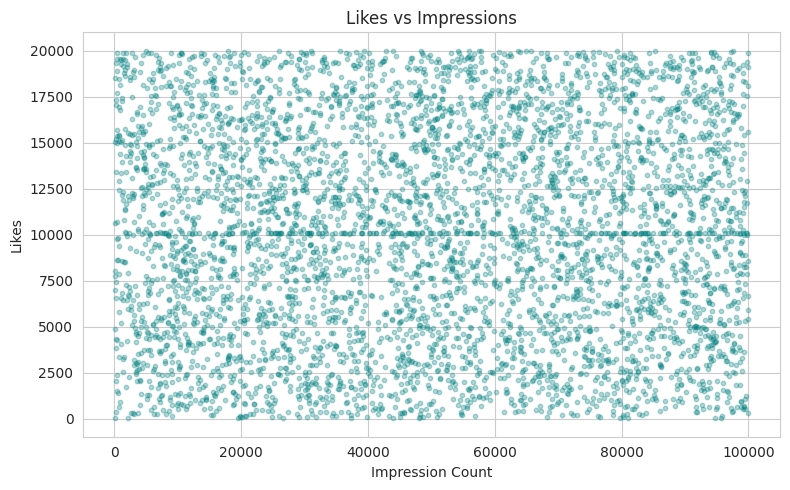

In [27]:
# Scatter: likes vs impressions — do more impressions translate into more likes?
plt.figure(figsize=(8, 5))
plt.scatter(df["impression_count"], df["likes"], alpha=0.3, s=10, color="teal")
plt.title("Likes vs Impressions")
plt.xlabel("Impression Count")
plt.ylabel("Likes")
plt.tight_layout()
plt.show()


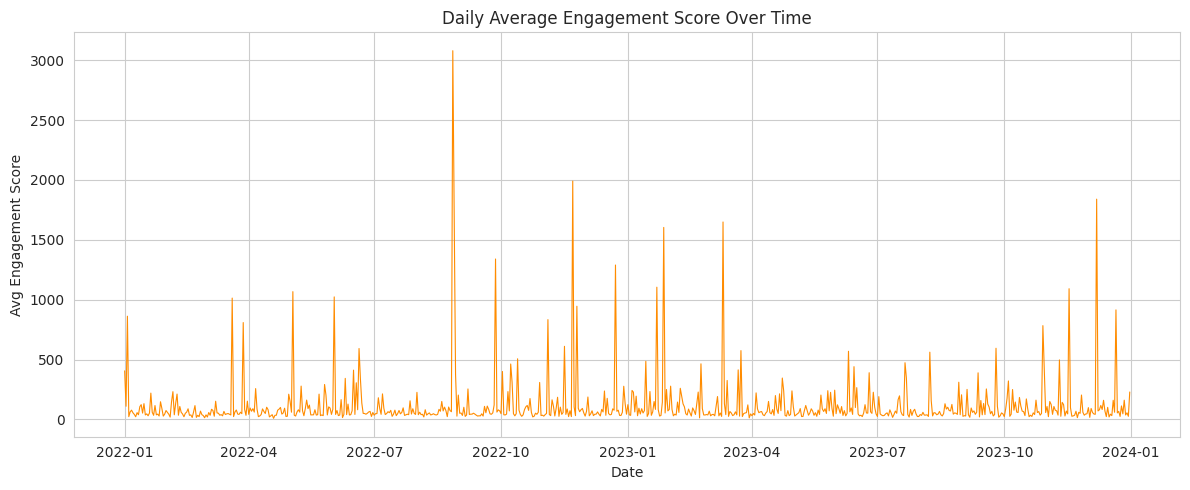

In [28]:
# Line: daily engagement trend — aggregate engagement_score by calendar day, then plot
# the trend over time to see whether engagement is rising, falling, or flat.
daily_engagement = df.groupby(df["posted_at"].dt.date)["engagement_score"].mean()

plt.figure(figsize=(12, 5))
plt.plot(daily_engagement.index, daily_engagement.values, linewidth=0.8, color="darkorange")
plt.title("Daily Average Engagement Score Over Time")
plt.xlabel("Date")
plt.ylabel("Avg Engagement Score")
plt.tight_layout()
plt.show()


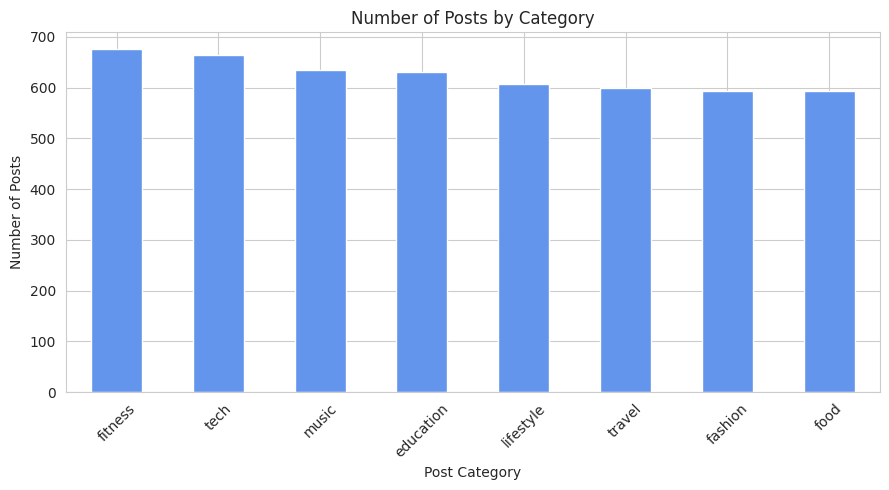

In [29]:
# Bar: posts by category — simple frequency count per post_category.
posts_by_category = df["post_category"].value_counts()

plt.figure(figsize=(9, 5))
posts_by_category.plot(kind="bar", color="cornflowerblue")
plt.title("Number of Posts by Category")
plt.xlabel("Post Category")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


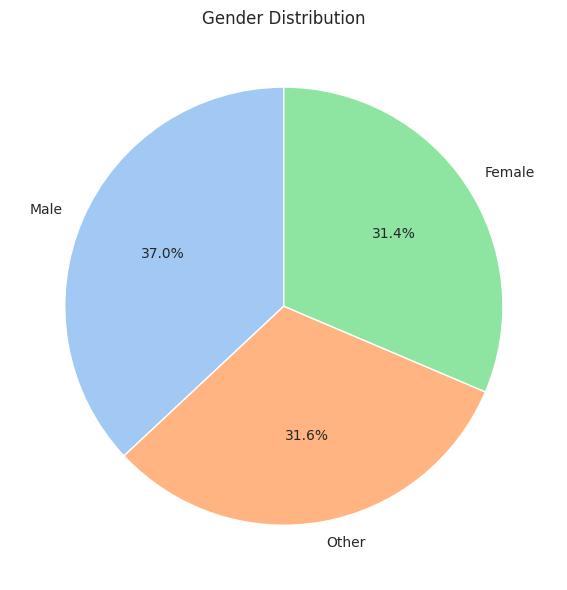

In [30]:
# Pie: gender distribution — share of posts coming from each gender group.
gender_counts = df["gender"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%",
        colors=sns.color_palette("pastel"), startangle=90)
plt.title("Gender Distribution")
plt.tight_layout()
plt.show()


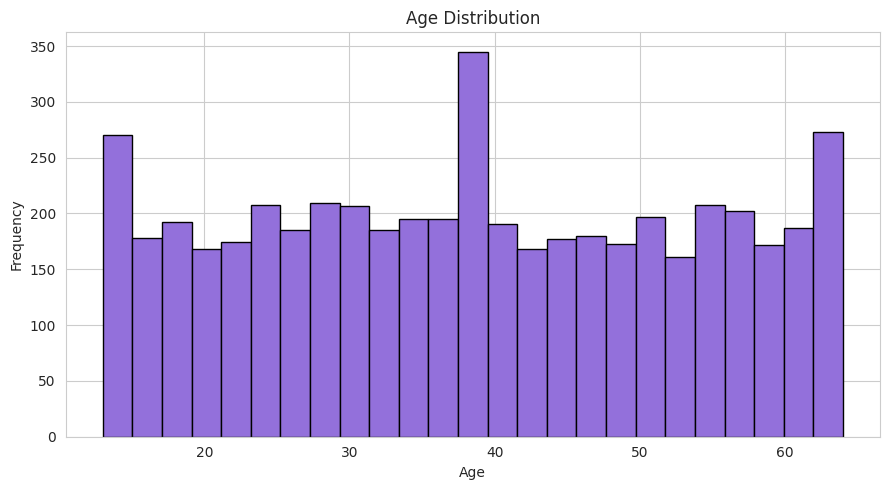

In [31]:
# Histogram: age — shape of the age distribution across all users.
plt.figure(figsize=(9, 5))
plt.hist(df["age"], bins=25, color="mediumpurple", edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


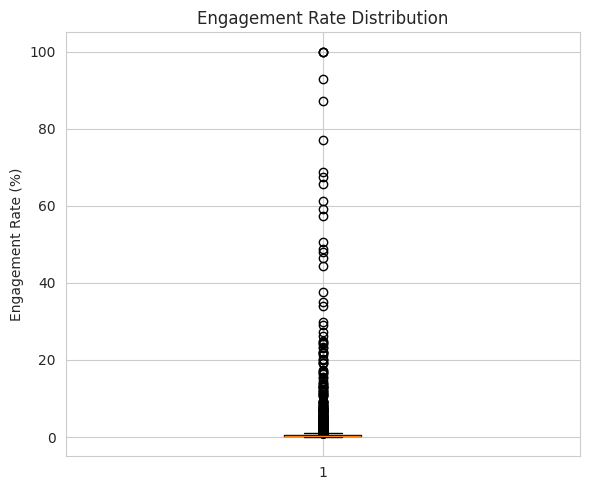

In [32]:
# Box: engagement rate — median, IQR, and any remaining outliers after our Task-2 capping.
plt.figure(figsize=(6, 5))
plt.boxplot(df["engagement_rate"], vert=True)
plt.title("Engagement Rate Distribution")
plt.ylabel("Engagement Rate (%)")
plt.tight_layout()
plt.show()


### Seaborn

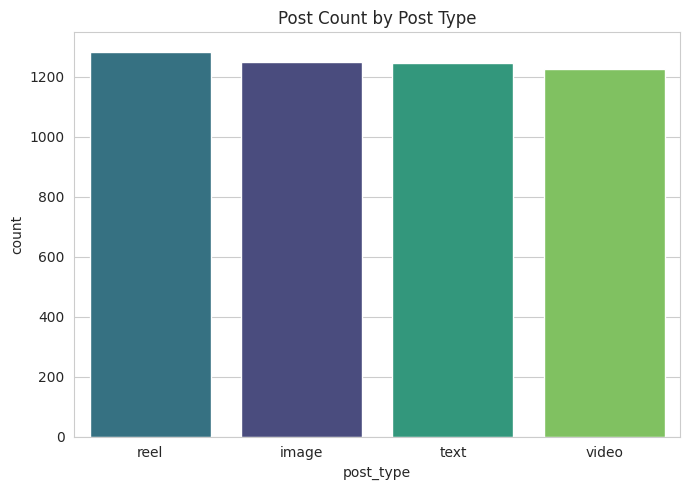

In [33]:
# Count plot: number of posts per post_type.
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="post_type", hue="post_type",
              order=df["post_type"].value_counts().index, palette="viridis", legend=False)
plt.title("Post Count by Post Type")
plt.tight_layout()
plt.show()


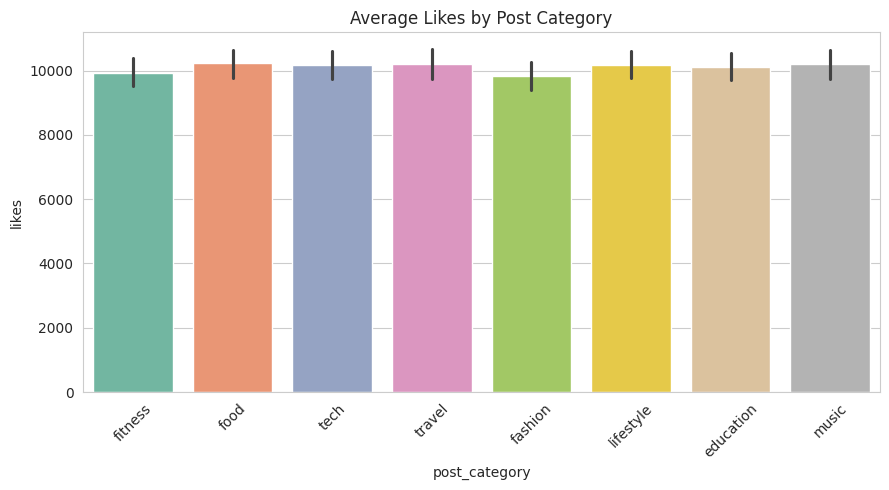

In [34]:
# Bar plot: average likes by post_category (Seaborn's barplot computes the mean +
# confidence interval automatically, unlike a plain Pandas bar chart of raw counts).
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="post_category", y="likes", hue="post_category",
            estimator="mean", palette="Set2", legend=False)
plt.title("Average Likes by Post Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


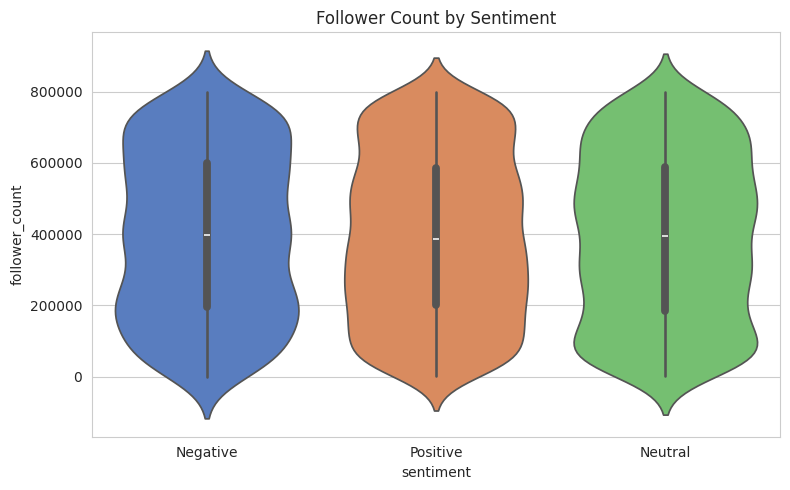

In [35]:
# Violin plot: follower_count distribution split by sentiment — shows both the spread
# and the density shape (wider = more posts at that follower level) per sentiment group.
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x="sentiment", y="follower_count", hue="sentiment",
               palette="muted", legend=False)
plt.title("Follower Count by Sentiment")
plt.tight_layout()
plt.show()


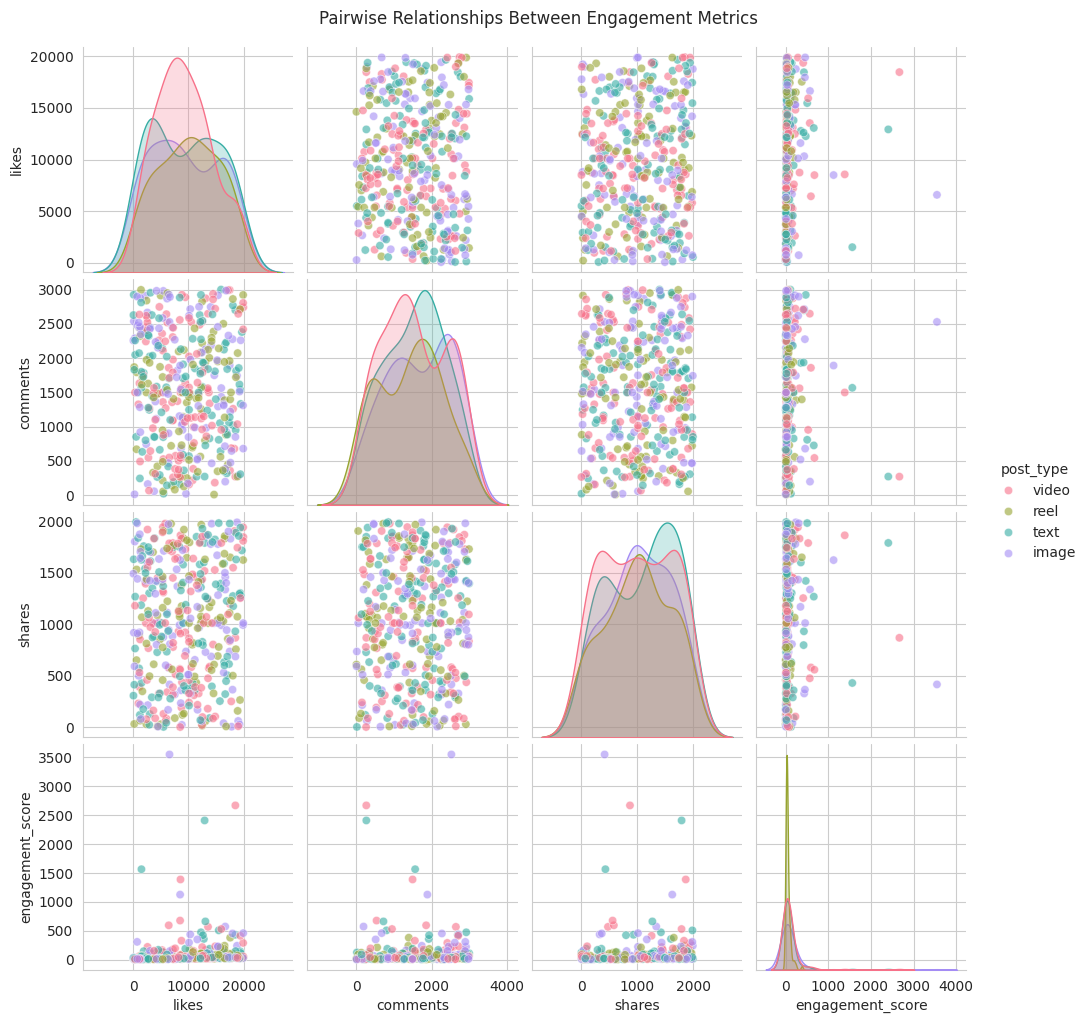

In [36]:
# Pair plot: pairwise scatter + histograms across key numeric features, colored by
# post_type so we can spot whether video/image/text/reel posts cluster differently.
sample_for_pairplot = df.sample(400, random_state=1)  # sample for a readable, fast-rendering plot
sns.pairplot(
    sample_for_pairplot[["likes", "comments", "shares", "engagement_score", "post_type"]],
    hue="post_type", palette="husl", plot_kws={"alpha": 0.6},
)
plt.suptitle("Pairwise Relationships Between Engagement Metrics", y=1.02)
plt.show()


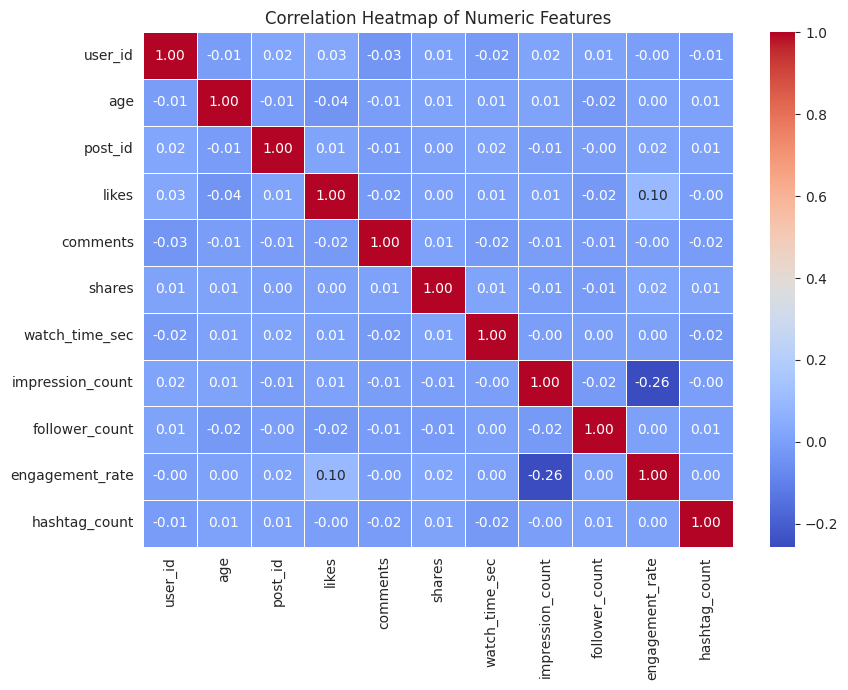

In [37]:
# Heatmap: correlation matrix (computed in Task 3) visualized with color + printed values.
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 39.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 39.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 36.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 42.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 42.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 38.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


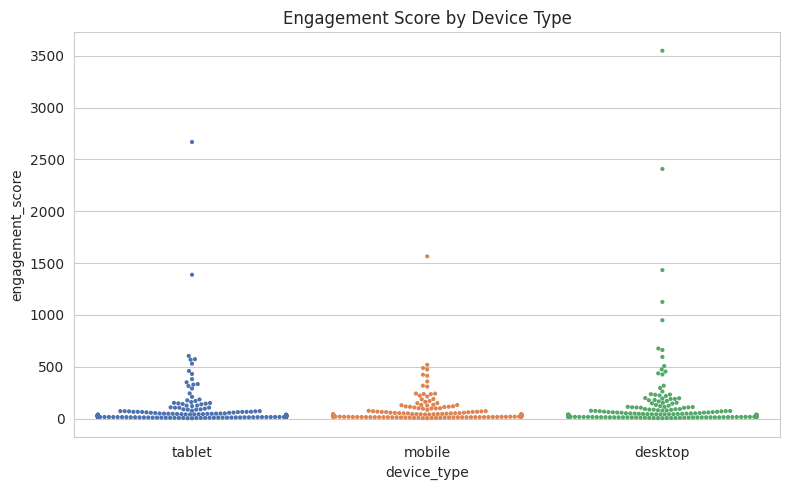

In [38]:
# Swarm plot: engagement_score vs device_type — each dot is one post, jittered so
# points don't overlap, giving a true sense of density per device (unlike a box plot's
# summary-only view). Sampled to keep the plot from getting overcrowded.
plt.figure(figsize=(8, 5))
sns.swarmplot(data=df.sample(600, random_state=1), x="device_type", y="engagement_score",
              hue="device_type", size=3, palette="deep", legend=False)
plt.title("Engagement Score by Device Type")
plt.tight_layout()
plt.show()


### Plotly (Interactive)

In [39]:
# Interactive line chart: daily engagement trend, hoverable and zoomable.
daily_df = daily_engagement.reset_index()
daily_df.columns = ["date", "avg_engagement_score"]

fig_line = px.line(daily_df, x="date", y="avg_engagement_score",
                    title="Interactive: Daily Average Engagement Score")
fig_line.show()


In [40]:
# Interactive bar chart: average engagement_rate by country, hover to see exact values.
avg_rate_by_country = df.groupby("country")["engagement_rate"].mean().reset_index()

fig_bar = px.bar(avg_rate_by_country.sort_values("engagement_rate", ascending=False),
                  x="country", y="engagement_rate",
                  title="Interactive: Average Engagement Rate by Country",
                  color="engagement_rate", color_continuous_scale="Blues")
fig_bar.show()


In [41]:
# Interactive bubble/scatter chart: likes vs comments, bubble size = shares,
# color = post_type — four dimensions of data visible in one interactive chart.
fig_bubble = px.scatter(
    df.sample(500, random_state=1), x="likes", y="comments",
    size="shares", color="post_type",
    hover_data=["country", "engagement_score"],
    title="Interactive: Likes vs Comments (bubble size = Shares)",
    opacity=0.6,
)
fig_bubble.show()


## Final Insights

In [42]:
# ---- Content Performance ----
print("Avg engagement_score by post_type:\n", df.groupby("post_type")["engagement_score"].mean().sort_values(ascending=False))
print("\nAvg engagement_score by post_category:\n", df.groupby("post_category")["engagement_score"].mean().sort_values(ascending=False))
print("\nAvg engagement_rate by country:\n", df.groupby("country")["engagement_rate"].mean().sort_values(ascending=False).head())


Avg engagement_score by post_type:
 post_type
video    139.701152
text     136.326186
image    114.473072
reel     102.100401
Name: engagement_score, dtype: float64

Avg engagement_score by post_category:
 post_category
food         171.045631
tech         143.947634
lifestyle    140.136557
music        115.458628
fitness      114.468999
education    105.938169
fashion      102.818252
travel        89.801324
Name: engagement_score, dtype: float64

Avg engagement_rate by country:
 country
brazil       1.359148
australia    1.279852
france       1.146402
uae          1.112352
canada       0.905446
Name: engagement_rate, dtype: float64


In [43]:
# ---- User Trends ----
# Correlation between age and engagement_score tells us if engagement rises/falls with age.
print("Correlation (age, engagement_score):", df["age"].corr(df["engagement_score"]).round(3))

# Compare verified vs non-verified accounts on average engagement.
print("\nAvg engagement_score, verified vs not:\n", df.groupby("is_verified")["engagement_score"].mean())


Correlation (age, engagement_score): 0.01

Avg engagement_score, verified vs not:
 is_verified
False    122.026704
True     131.279766
Name: engagement_score, dtype: float64


In [44]:
# ---- Behavioral Insights ----
# Best time of day for impressions (requires an hour component; this dataset only has a
# date, not a timestamp with hour, so we note that limitation rather than fabricate an hour).
print("Note: 'posted_at' contains only a date (no time-of-day), so hour-level analysis of")
print("impressions isn't possible with the columns provided in this dataset.")

print("\nAvg watch_time_sec by device_type:\n", df.groupby("device_type")["watch_time_sec"].mean().sort_values(ascending=False))


Note: 'posted_at' contains only a date (no time-of-day), so hour-level analysis of
impressions isn't possible with the columns provided in this dataset.

Avg watch_time_sec by device_type:
 device_type
mobile     4087.830760
tablet     3979.736429
desktop    3974.792521
Name: watch_time_sec, dtype: float64


In [45]:
# ---- Sentiment Analysis ----
print("Avg engagement_score by sentiment:\n", df.groupby("sentiment")["engagement_score"].mean().sort_values(ascending=False))
print("\nAvg shares by sentiment (proxy for how 'shareable' each sentiment is):\n", df.groupby("sentiment")["shares"].mean().sort_values(ascending=False))


Avg engagement_score by sentiment:
 sentiment
Negative    132.848961
Neutral     127.883241
Positive    116.112231
Name: engagement_score, dtype: float64

Avg shares by sentiment (proxy for how 'shareable' each sentiment is):
 sentiment
Negative    1007.307292
Positive    1005.086749
Neutral      996.565160
Name: shares, dtype: float64
